In [1]:
import importlib
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

import model as _model_mod; importlib.reload(_model_mod)
import data as _data_mod;   importlib.reload(_data_mod)
import flow as _flow_mod;   importlib.reload(_flow_mod)

from model import MLPVelocity, ConditionalMLPVelocity
from data import SwissrollWithLabel, sample_noise
from flow import flow_pair, sample_t, flow_matching_loss, sample_trajectory

def plot_batch(batch, **kwargs):
    arr = batch.cpu().numpy()
    plt.scatter(arr[:, 0], arr[:, 1], marker='.', **kwargs)

def moving_average(x, w):
    return np.convolve(x, np.ones(w), 'valid') / w

# Load pre-trained unconditional backbone

Load weights saved by `pretrain.ipynb`.  The backbone already knows the general Swiss-roll velocity field; we only need to teach it to use condition labels.

In [2]:
device = torch.device('cpu')
backbone = MLPVelocity().to(device)
backbone.load_state_dict(torch.load('pretrained_backbone.pt', map_location=device, weights_only=True))
backbone.eval()
print('Backbone loaded ✓')

Backbone loaded ✓


/opt/homebrew/anaconda3/envs/rl/lib/python3.10/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


# Build conditional model

`ConditionalMLPVelocity.from_pretrained` copies all backbone weights verbatim, except the first Linear layer whose input dimension is expanded by `cond_dim`.  The new weight columns are **zero-initialised**, so at the start of fine-tuning the model behaves identically to the unconditional backbone.

In [3]:
cond_model = ConditionalMLPVelocity.from_pretrained(
    backbone,
    cond_dim=4,
    num_classes=SwissrollWithLabel.NUM_CLASSES,
    dropout_prob=0.1,
).to(device)

print(f'Conditional model built (cond_dim=4, num_classes={SwissrollWithLabel.NUM_CLASSES}) ✓')

Conditional model built (cond_dim=4, num_classes=7) ✓


# Data

Load `SwissrollWithLabel` — a 2D Swiss roll split into 7 class segments (see `test.ipynb` for the stand-alone visualisation).

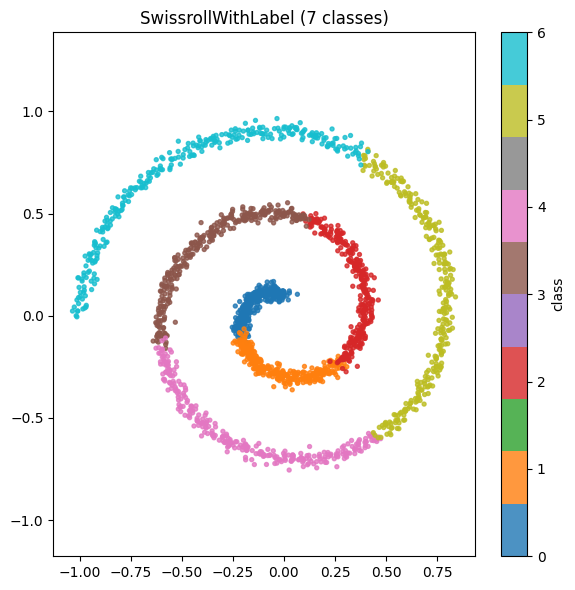

In [4]:
dataset = SwissrollWithLabel()
loader = DataLoader(dataset, batch_size=len(dataset))

pts = np.array([dataset[i][0].numpy() for i in range(len(dataset))])
labels = np.array([dataset[i][1] for i in range(len(dataset))])

plt.figure(figsize=(6, 6))
scatter = plt.scatter(pts[:, 0], pts[:, 1], c=labels, cmap='tab10', s=8, alpha=0.8)
plt.colorbar(scatter, label='class')
plt.axis('equal')
plt.title('SwissrollWithLabel (7 classes)')
plt.tight_layout()
plt.show()

# Fine-tune

Flow matching with conditional labels.  The pre-trained backbone already knows the general velocity field; we only need to teach it to use class information.

In [5]:
torch.manual_seed(42)
epochs = 5000
opt = torch.optim.Adam(cond_model.parameters(), lr=1e-4)
losses = []

for epoch in range(epochs):
    cond_model.train()
    for x1_b, labels_b in loader:
        x1_b = x1_b.to(device)
        labels_b = labels_b.to(device)
        x0 = sample_noise(x1_b.size(0), device=device)
        t = sample_t(x1_b.size(0), device)
        x_t, target_v = flow_pair(x0, x1_b, t)
        pred_v = cond_model(x_t, t, labels_b)
        loss = flow_matching_loss(pred_v, target_v)
        opt.zero_grad()
        loss.backward()
        opt.step()
        losses.append(loss.item())

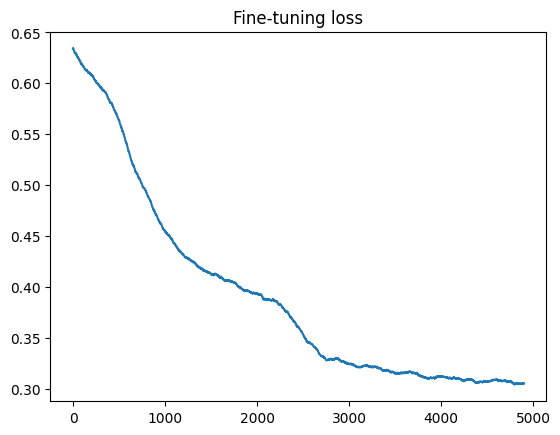

In [6]:
plt.plot(moving_average(losses, 100))
plt.title('Fine-tuning loss')
plt.show()

# Conditional sampling

Generate samples conditioned on each class label (0–6) plus unconditional samples (label = 7).

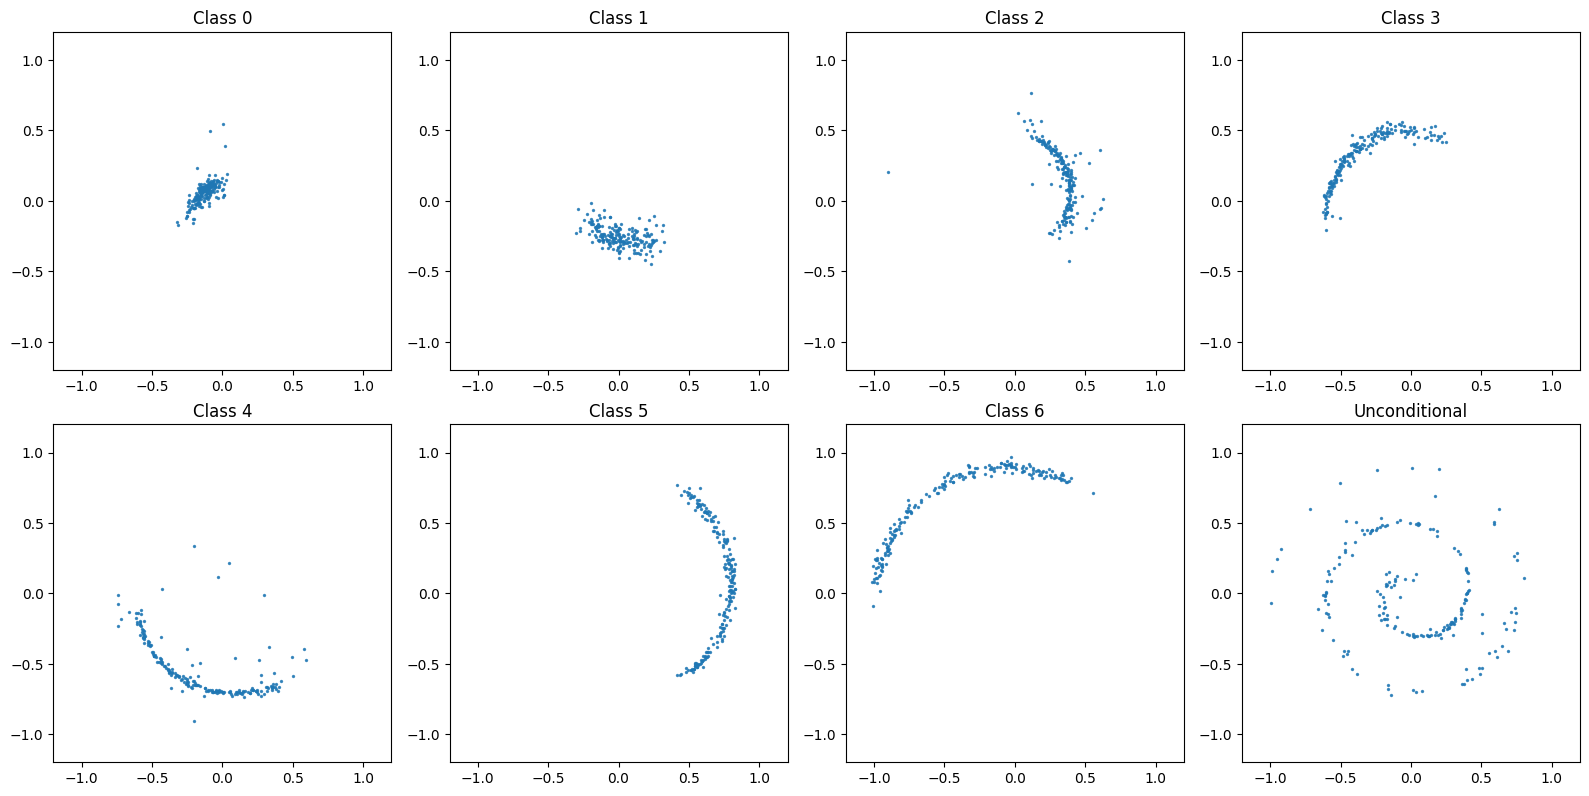

In [9]:
cond_model.eval()
n_per_class = 200
num_classes = SwissrollWithLabel.NUM_CLASSES

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for label in range(num_classes + 1):
    ax = axes[label // 4, label % 4]
    x0 = sample_noise(n_per_class, device=device, seed=label)
    label_t = torch.full((n_per_class,), label, dtype=torch.long, device=device)
    traj = sample_trajectory(
        x0,
        lambda x, t, c=label_t: cond_model(x, t, c),
        n_steps=80,
    )
    x1 = traj['xs'][-1].cpu().numpy()
    ax.scatter(x1[:, 0], x1[:, 1], marker='.', s=8, alpha=0.8)
    title = f'Class {label}' if label < num_classes else 'Unconditional'
    ax.set_title(title)
    ax.set_aspect('equal')
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)

plt.tight_layout()
plt.show()

# Save

Save the fine-tuned model for alignment use as `conditioned_backbone.pt`.

In [10]:
torch.save(cond_model.state_dict(), 'conditioned_backbone.pt')

## Animation

Eight panels (7 classes + unconditional): particle motion $t\in[0,1]$ and velocity field on a grid. Same layout as the conditional sampling figure. **Fixed** global $\|\mathbf{v}\|$ range with **log** color scale; arrows have uniform length, color encodes speed. Outputs `finetune-colored.gif` (jet) and `finetune-gray.gif` (Greys). Requires trained `cond_model` or `conditioned_backbone.pt`.


In [ ]:
import numpy as np
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.colors import LogNorm

from model import ConditionalMLPVelocity
from data import SwissrollWithLabel, sample_noise
from flow import sample_trajectory

mpl.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["DejaVu Serif", "Times New Roman", "Times", "serif"],
        "mathtext.fontset": "dejavuserif",
        "font.size": 9,
        "axes.labelsize": 10,
        "axes.titlesize": 11,
        "figure.facecolor": "white",
        "axes.facecolor": "#f7f7f8",
        "axes.edgecolor": "#2d2d2d",
        "axes.linewidth": 0.85,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
    }
)

device = torch.device("cpu")
try:
    _cm = cond_model
except NameError:
    _cm = ConditionalMLPVelocity(
        cond_dim=4,
        num_classes=SwissrollWithLabel.NUM_CLASSES,
        dropout_prob=0.1,
    ).to(device)
    _cm.load_state_dict(torch.load("conditioned_backbone.pt", map_location=device, weights_only=True))
_cm.eval()

num_classes = SwissrollWithLabel.NUM_CLASSES
n_panels = num_classes + 1
n_steps = 80
n_per_class = 160
lim = 1.2
ng = 13
pause_frames = 36

# One trajectory per panel (same seeds as the static sampling figure)
trajectories = []
for label in range(n_panels):
    x0 = sample_noise(n_per_class, device=device, seed=label)
    label_t = torch.full((n_per_class,), label, dtype=torch.long, device=device)
    with torch.no_grad():
        traj = sample_trajectory(
            x0,
            lambda x, t, c=label_t: _cm(x, t, c),
            n_steps=n_steps,
        )
    trajectories.append(traj["xs"].cpu().numpy())

times = np.linspace(0.0, 1.0, n_steps + 1)

gx = np.linspace(-lim, lim, ng)
gy = np.linspace(-lim, lim, ng)
GX, GY = np.meshgrid(gx, gy, indexing="xy")
grid_np = np.stack([GX.ravel(), GY.ravel()], axis=1).astype(np.float32)
grid_t = torch.from_numpy(grid_np).to(device)

all_speeds = []
panel_UVS = []
for label in range(n_panels):
    lbl = torch.full((grid_t.shape[0],), label, dtype=torch.long, device=device)
    U_list, V_list, S_list = [], [], []
    for k in range(n_steps + 1):
        tk = float(times[k])
        tt = torch.full((grid_t.shape[0], 1), tk, device=device, dtype=torch.float32)
        with torch.no_grad():
            v = _cm(grid_t, tt, lbl).cpu().numpy()
        U = v[:, 0].reshape(ng, ng)
        Vv = v[:, 1].reshape(ng, ng)
        spd = np.hypot(U, Vv)
        U_list.append(U)
        V_list.append(Vv)
        S_list.append(spd)
        all_speeds.append(spd.ravel())
    panel_UVS.append((U_list, V_list, S_list))

spd_flat = np.concatenate(all_speeds)
spd_pos = spd_flat[spd_flat > 0]
if spd_pos.size == 0:
    v_lo, v_hi = 1e-4, 1.0
else:
    v_lo = float(np.percentile(spd_pos, 2))
    v_hi = float(np.percentile(spd_pos, 99.8))
    v_lo = max(v_lo, 1e-5)
    if v_hi <= v_lo * 1.01:
        v_hi = v_lo * 10.0

quiver_norm = LogNorm(vmin=v_lo, vmax=v_hi)

cell = (2 * lim) / max(ng - 1, 1)
arrow_len = 0.40 * cell


def run_animation(cmap_name: str, out_path: str, quiver_alpha: float) -> None:
    try:
        cmap = mpl.colormaps[cmap_name]
    except (AttributeError, KeyError):
        cmap = mpl.cm.get_cmap(cmap_name)

    fig, axes = plt.subplots(2, 4, figsize=(16, 8.2), dpi=120)
    plt.subplots_adjust(left=0.06, right=0.93, top=0.90, bottom=0.07, wspace=0.22, hspace=0.30)
    axes_flat = axes.ravel()

    Qs = []
    scats = []
    for p, ax in enumerate(axes_flat):
        Q = ax.quiver(
            GX,
            GY,
            np.zeros_like(GX),
            np.zeros_like(GY),
            np.zeros_like(GX),
            cmap=cmap,
            norm=quiver_norm,
            angles="xy",
            scale_units="xy",
            scale=1.0,
            width=0.0018,
            headwidth=3.0,
            headlength=3.8,
            headaxislength=3.0,
            zorder=2,
            alpha=quiver_alpha,
        )
        scat = ax.scatter(
            trajectories[p][0, :, 0],
            trajectories[p][0, :, 1],
            s=5,
            c="#16213e",
            alpha=0.78,
            linewidths=0,
            zorder=4,
        )
        Qs.append(Q)
        scats.append(scat)
        ax.set_xlim(-lim, lim)
        ax.set_ylim(-lim, lim)
        ax.set_aspect("equal", adjustable="box")
        ax.grid(True, color="#b8b8c0", linewidth=0.45, linestyle="--", alpha=0.75)
        ax.set_axisbelow(True)
        ax.set_title(f"Class {p}" if p < num_classes else "Unconditional", fontsize=11)

    cbar = fig.colorbar(Qs[0], ax=list(axes_flat), fraction=0.022, pad=0.02)
    cbar.set_label(fr"$\|\mathbf{{v}}_{{\mathrm{{base}}}}(\mathbf{x}, t \mid c)\|$ (log scale)", rotation=270, labelpad=16)

    def _frame(i: int):
        i = int(i)
        k = n_steps if i > n_steps else i
        t = float(times[k])
        for p in range(n_panels):
            scats[p].set_offsets(trajectories[p][k])
            U_list, V_list, S_list = panel_UVS[p]
            U, Vv, spd = U_list[k], V_list[k], S_list[k]
            mag = np.hypot(U, Vv)
            U_n = U / (mag + 1e-9)
            V_n = Vv / (mag + 1e-9)
            spd_c = np.maximum(np.clip(spd, v_lo, v_hi), v_lo)
            Qs[p].set_UVC(U_n * arrow_len, V_n * arrow_len, spd_c)

        if k == n_steps and i > n_steps:
            st = r"Conditional fine-tuning $\mathbf{{v}}_{{\mathrm{{base}}}}$: $t = 1.000$  (hold)"
        else:
            st = rf"Conditional fine-tuning $\mathbf{{v}}_{{\mathrm{{base}}}}$: $t = {t:.3f}$"
        fig.suptitle(st, fontsize=13, y=0.995)

    anim = FuncAnimation(
        fig,
        _frame,
        frames=n_steps + 1 + pause_frames,
        interval=55,
        blit=False,
    )
    writer = PillowWriter(fps=18)
    anim.save(out_path, writer=writer, dpi=110)
    plt.close(fig)
    print(f"Saved: {out_path}")


run_animation("jet", "finetune-colored.gif", 0.58)
run_animation("Greys", "finetune-gray.gif", 0.72)


Saved: finetune-colored.gif
Saved: finetune-gray.gif
